가상환경설정과 requirements을 설치

powersell에 .\.venv_nb\Scripts\python.exe -m pip install -r requirements.txt 입력

서버 실행 도우미

In [9]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
import os, sys, asyncio, threading, time, socket, contextlib
import uvicorn

# 작업 디렉터리를 app/ 가 있는 위치로 맞춥니다 (notebooks/ 안에서 열어도 동작).
if not os.path.isdir('app') and os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# 코드를 저장할 폴더를 미리 만들어 둡니다.
for _d in ('app', 'models', 'data', 'frontend'):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다."""
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if _port_open(host, port):
        print(f'⚠️ 포트 {port}를 다른 프로세스가 사용 중입니다 (다른 노트북의 서버일 가능성).')
        print('   그 노트북에서 stop_server(8000)을 실행하거나 커널을 종료한 뒤, 이 셀을 다시 실행하세요.')
        return None
    if isinstance(app, str):
        sys.modules.pop(app.split(':')[0], None)   # 파일을 다시 저장한 경우 최신 내용 반영
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        # Windows는 SelectorEventLoop, 그 외는 기본 이벤트 루프를 사용합니다.
        if sys.platform == 'win32':
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    # 모델 로드 때문에 기동이 느릴 수 있다 — 최대 5분 대기 (첫 실행은 다운로드 포함)
    for i in range(600):
        if _port_open(host, port):
            print(f'서버 실행됨: http://{host}:{port}')
            return server
        if not thread.is_alive():
            print('서버 스레드가 종료됐습니다. 위 로그를 확인하세요.')
            return server
        if i > 0 and i % 20 == 0:
            print(f'  ... 모델 로드 중 ({i//2}초 경과)')
        time.sleep(0.5)
    print('5분 내에 서버가 시작되지 않았습니다. 위 로그를 확인하세요.')
    return server

print('서버 도우미 준비 완료 (serve_in_thread, stop_server)')

서버 도우미 준비 완료 (serve_in_thread, stop_server)


금융 정보 감성 분석

사용 모델: "snunlp/KR-FinBert-SC"  
모델의 태스크: text-classification   
서울대 SNU NLP Lab의 KR-FinBert 계열 모델입니다. KR-FinBert는 금융 도메인 말뭉치로 추가 사전학습한 뒤 감성 분석에 fine-tuning한 모델로 설명됩니다. 관련 자료에 따르면 학습 데이터에는 뉴스 제목·본문 440,067건과 애널리스트 리포트 11,237건이 포함되어 있고, 전체 데이터 크기는 약 13.22GB입니다.   
분석 태스크 중 한국어 금융 도메인에 특화

In [2]:
# 예시: 텍스트 감정 분석
from transformers import pipeline

# 본인이 선택한 모델로 교체하세요
classifier = pipeline("text-classification", model="snunlp/KR-FinBert-SC")

result = classifier("오늘 주가가 크게 올랐습니다")
print(result)
# [{'label': 'positive', 'score': 0.95}]

d:\model-serving-course\.venv_nb\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 28307.54it/s]


[{'label': 'positive', 'score': 0.9987346529960632}]


환경구축시 requirements.txt 속 torch<2.5.0 torch이였고 현재 버젼이 2.4.1이라 transformers가 모델 로드를 막았고, torch만 올리자 torchvision이 충돌했습니다. 둘을 같이 맞춘 뒤에는 snunlp/KR-FinBert-SC 모델 로드와 금융 정보 분석일 실행했다.

프로젝트 뼈대 코드

폴더 구조

In [3]:
import os

dirs = ["app", "models", "frontend"]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("프로젝트 구조:")
print("""
my-project/
├── 📁 app/
│   ├── auth.py              ← Day 6에서 만든 것 그대로 재사용
│   ├── schemas.py           ← 입력/출력 스키마 정의 (직접 작성)
│   ├── model_service.py     ← 모델 로드 + 추론 함수 (직접 작성)
│   └── main.py              ← FastAPI 서버 (직접 작성)
│
├── 📁 frontend/
│   └── app.py               ← Streamlit UI (직접 작성)
│
└── requirements.txt
""")

프로젝트 구조:

my-project/
├── 📁 app/
│   ├── auth.py              ← Day 6에서 만든 것 그대로 재사용
│   ├── schemas.py           ← 입력/출력 스키마 정의 (직접 작성)
│   ├── model_service.py     ← 모델 로드 + 추론 함수 (직접 작성)
│   └── main.py              ← FastAPI 서버 (직접 작성)
│
├── 📁 frontend/
│   └── app.py               ← Streamlit UI (직접 작성)
│
└── requirements.txt



인증 모듈 그대로 활용

In [2]:
%%writefile app/auth.py
"""
Day 6에서 만든 인증 모듈을 그대로 재사용합니다.
"""
from fastapi import HTTPException, Header

VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )
    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )
    return VALID_API_KEYS[x_api_key]

Writing app/auth.py


스키마 작성

In [4]:
%%writefile app/schemas.py
"""
입력/출력 스키마를 정의하세요.

참고: Day 2 섹션 4 (Pydantic 기초), Day 5 섹션 3 (HousingRequest)

TODO:
  - 본인의 모델 입력에 맞는 Request 스키마를 정의하세요.
  - 모델 출력에 맞는 Response 스키마를 정의하세요.
  - 필수 필드와 선택 필드를 구분하세요.
  - 적절한 검증 규칙(타입, 범위, 길이 등)을 추가하세요.




금융 뉴스 감성 분석 모델용 Pydantic 스키마
- 입력: 금융/경제 관련 문장 text
- 출력: 예측 성공 여부, 감성 라벨, 신뢰도
- 제한: 일반적인 감정 분석은 어색할 수 있다.
"""
from pydantic import BaseModel, Field

class PredictRequest(BaseModel):
    """
    감성 분석 요청 스키마
    """

    text: str = Field(
        ...,
        min_length=1,
        max_length=1000,
        description="감성 분석할 금융/경제 관련 문장",
        examples=[
            "삼성 이재용회장 젠슨황과 깐부치킨에서 돈독한 회동을 가져."

        ]
    )


class PredictResponse(BaseModel):
    """
    감성 분석 응답 스키마
    """

    success: bool = Field(
        ...,
        description="예측 성공 여부"
    )

    label: str = Field(
        ...,
        description="예측된 감성 라벨"
    )

    confidence: float = Field(
        ...,
        ge=0.0,
        le=1.0,
        description="예측 신뢰도"
    )

Overwriting app/schemas.py


나중에 사용할 model.py의 반환값 :   
return {  
    "success": True,  
    "label": result["label"],  
    "confidence": float(result["score"])  

model_service.py — 직접 작성

In [3]:
%%writefile app/model_service.py
"""
모델 로드와 추론 함수를 정의하세요.

금융 뉴스 감성 분석 모델:
- 모델: snunlp/KR-FinBert-SC
- 태스크: text-classification
"""

from transformers import pipeline


MODEL_NAME = "snunlp/KR-FinBert-SC"


def load_model():
    """
    사전학습된 한국어 금융 감성분석 모델을 로드합니다.

    Returns:
        transformers Pipeline 객체
    """
    model = pipeline(
        task="text-classification",
        model=MODEL_NAME,
        tokenizer=MODEL_NAME
    )

    return model


def predict(model, text: str) -> dict:
    """
    입력 문장에 대한 금융 감성 분석을 수행합니다.

    Args:
        model: load_model()에서 반환된 pipeline 객체
        text: 감성 분석할 금융/경제 문장

    Returns:
        dict: 예측 결과
    """

    if not isinstance(text, str):
        raise TypeError("입력값은 문자열이어야 합니다.")

    text = text.strip()

    if not text:
        raise ValueError("입력 문장이 비어 있습니다.")

    result = model(
        text,
        truncation=True
    )

    pred = result[0]

    return {
        "success": True,
        "label": str(pred["label"]),
        "confidence": round(float(pred["score"]), 4)
    }

Writing app/model_service.py


main.py — 직접 작성

In [5]:
%%writefile app/main.py
"""
FastAPI 서버를 정의하세요.

금융 뉴스 감성 분석 API
- 모델: snunlp/KR-FinBert-SC
- 인증: API Key
- 추론: run_in_executor를 사용한 비동기 처리
"""

import asyncio
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, Depends, HTTPException

from app.auth import verify_api_key
from app.schemas import PredictRequest, PredictResponse
from app.model_service import load_model, predict


# 전역 모델 객체
model = None

# 모델 추론용 ThreadPoolExecutor
# 텍스트 분류 모델은 2 정도로 충분
inference_executor = ThreadPoolExecutor(max_workers=2)


app = FastAPI(
    title="KR-FinBERT Financial Sentiment API",
    description="snunlp/KR-FinBert-SC 모델을 활용한 한국어 금융 뉴스 감성 분석 API",
    version="1.0.0",
)


@app.on_event("startup")
async def startup_event():
    """
    서버 시작 시 모델을 한 번만 로드합니다.
    """
    global model

    try:
        model = load_model()
        print(" 모델 로드 완료")

    except Exception as e:
        model = None
        print(f" 모델 로드 실패: {type(e).__name__} - {e}")


@app.get("/health", tags=["System"])
async def health_check():
    """
    서버 및 모델 상태 확인 엔드포인트
    """
    return {
        "status": "healthy" if model is not None else "loading",
        "model_loaded": model is not None,
        "model_name": "snunlp/KR-FinBert-SC",
    }


@app.post(
    "/predict",
    response_model=PredictResponse,
    tags=["Prediction"],
)
async def predict_sentiment(
    request: PredictRequest,
    api_key: str = Depends(verify_api_key),
):
    """
    금융/경제 문장 감성 분석 엔드포인트
    """

    if model is None:
        raise HTTPException(
            status_code=503,
            detail="모델이 아직 로드되지 않았습니다.",
        )

    try:
        loop = asyncio.get_running_loop()

        result = await loop.run_in_executor(
            inference_executor,
            predict,
            model,
            request.text,
        )

        return result

    except ValueError as e:
        raise HTTPException(
            status_code=400,
            detail=str(e),
        )

    except TypeError as e:
        raise HTTPException(
            status_code=400,
            detail=str(e),
        )

    except Exception as e:
        print(f"❌ 추론 오류: {type(e).__name__} - {e}")

        raise HTTPException(
            status_code=500,
            detail="모델 추론 중 오류가 발생했습니다.",
        )

Writing app/main.py


startup()과 lifespan():   
startup 이벤트와 lifespan은 모두 서버 시작 시 모델을 한 번만 로드하기 위한 방법입니다. startup은 기존 방식이고 수업 코드와 연결성이 좋습니다. 반면 lifespan은 최신 FastAPI에서 권장되는 방식으로, 서버 시작과 종료 시점의 리소스 관리를 한 함수에서 처리할 수 있다는 장점이 있습니다.


왜 lifespan이 좋으냐면 모델 서비스에서는 시작할 때 모델을 로드하고, 종료할 때 리소스를 정리할 수 있어야 합니다.     
서버 시작 → 모델 로드    
서버 실행 중 → 예측 요청 처리    
서버 종료 → 모델 객체 정리, GPU 메모리 해제, executor 종료     
lifespan은 이 흐름을 한 곳에 모을 수 있습니다.

frontend/app.py — 직접 작성

In [6]:
%%writefile frontend/app.py
"""
Streamlit 프론트엔드를 정의하세요.

금융 뉴스 감성 분석 서비스
- 사용자 입력: 금융/경제 관련 문장
- API 호출: FastAPI POST /predict
- 결과 표시: 감성 라벨, 신뢰도
"""

import streamlit as st
import requests


# ===== 페이지 설정 =====
st.set_page_config(
    page_title="금융 뉴스 감성 분석",
    page_icon="📈",
    layout="centered",
)


# ===== 기본 설정 =====
API_BASE = "http://localhost:8000"


# ===== 제목 =====
st.title("📈 금융 뉴스 감성 분석 서비스")

st.write(
    """
    한국어 금융/경제 문장을 입력하면  
    `snunlp/KR-FinBert-SC` 모델이 문장의 감성을 분류합니다.
    """
)


# ===== 사이드바 =====
st.sidebar.header("API 설정")

api_url = st.sidebar.text_input(
    "API 서버 주소",
    value=API_BASE,
)

api_key = st.sidebar.text_input(
    "API Key",
    type="password",
    placeholder="API Key를 입력하세요",
)


# ===== 입력 영역 =====
st.subheader("분석할 문장 입력")

text = st.text_area(
    "금융/경제 관련 문장을 입력하세요",
    placeholder="예: 4분기 실적이 시장 기대치를 상회했다.",
    height=120,
)

example_texts = [
    "4분기 실적이 시장 기대치를 상회했다.",
    "환율 급등으로 수입 기업의 비용 부담이 커지고 있다.",
    "반도체 업황 회복 기대감에 관련주가 상승했다.",
    "글로벌 경기 둔화 우려로 투자 심리가 위축됐다.",
]

selected_example = st.selectbox(
    "예시 문장 선택",
    ["직접 입력"] + example_texts,
)

if selected_example != "직접 입력":
    text = selected_example
    st.info(f"선택한 예시: {text}")


# ===== API 호출 버튼 =====
if st.button("감성 분석하기"):
    if not api_key.strip():
        st.error("API Key를 입력해주세요.")

    elif not text.strip():
        st.error("분석할 문장을 입력해주세요.")

    else:
        try:
            response = requests.post(
                f"{api_url}/predict",
                json={"text": text},
                headers={"x-api-key": api_key},
                timeout=30,
            )

            if response.status_code == 200:
                result = response.json()

                st.success("분석 완료")

                label = result["label"]
                confidence = result["confidence"]

                col1, col2 = st.columns(2)

                with col1:
                    st.metric("예측 라벨", label)

                with col2:
                    st.metric("신뢰도", f"{confidence:.4f}")

                st.json(result)

                if "positive" in label.lower() or "pos" in label.lower():
                    st.info("긍정적인 금융 문장으로 예측되었습니다.")
                elif "negative" in label.lower() or "neg" in label.lower():
                    st.warning("부정적인 금융 문장으로 예측되었습니다.")
                else:
                    st.write("중립 또는 기타 라벨로 예측되었습니다.")

            elif response.status_code == 401:
                st.error("API Key 인증에 실패했습니다.")

            elif response.status_code == 400:
                detail = response.json().get("detail", "잘못된 입력입니다.")
                st.error(f"입력 오류: {detail}")

            elif response.status_code == 422:
                st.error("입력값 검증에 실패했습니다. 문자열 형식으로 입력해주세요.")

            elif response.status_code == 503:
                st.error("모델이 아직 로드되지 않았습니다. 잠시 후 다시 시도해주세요.")

            else:
                st.error(f"서버 오류가 발생했습니다. 상태 코드: {response.status_code}")
                try:
                    st.json(response.json())
                except Exception:
                    st.write(response.text)

        except requests.exceptions.ConnectionError:
            st.error("FastAPI 서버에 연결할 수 없습니다. 백엔드 서버를 먼저 실행해주세요.")

        except requests.exceptions.Timeout:
            st.error("요청 시간이 초과되었습니다.")

        except Exception as e:
            st.error(f"예상치 못한 오류가 발생했습니다: {type(e).__name__}")

Writing frontend/app.py


서버 실행

In [10]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.main:app", port=8000)

d:\model-serving-course\.venv_nb\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 209298.69it/s]


 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


서버 상태 확인

In [11]:
import requests

response = requests.get("http://127.0.0.1:8000/health")
print(response.status_code)
print(response.json())

200
{'status': 'healthy', 'model_loaded': True, 'model_name': 'snunlp/KR-FinBert-SC'}


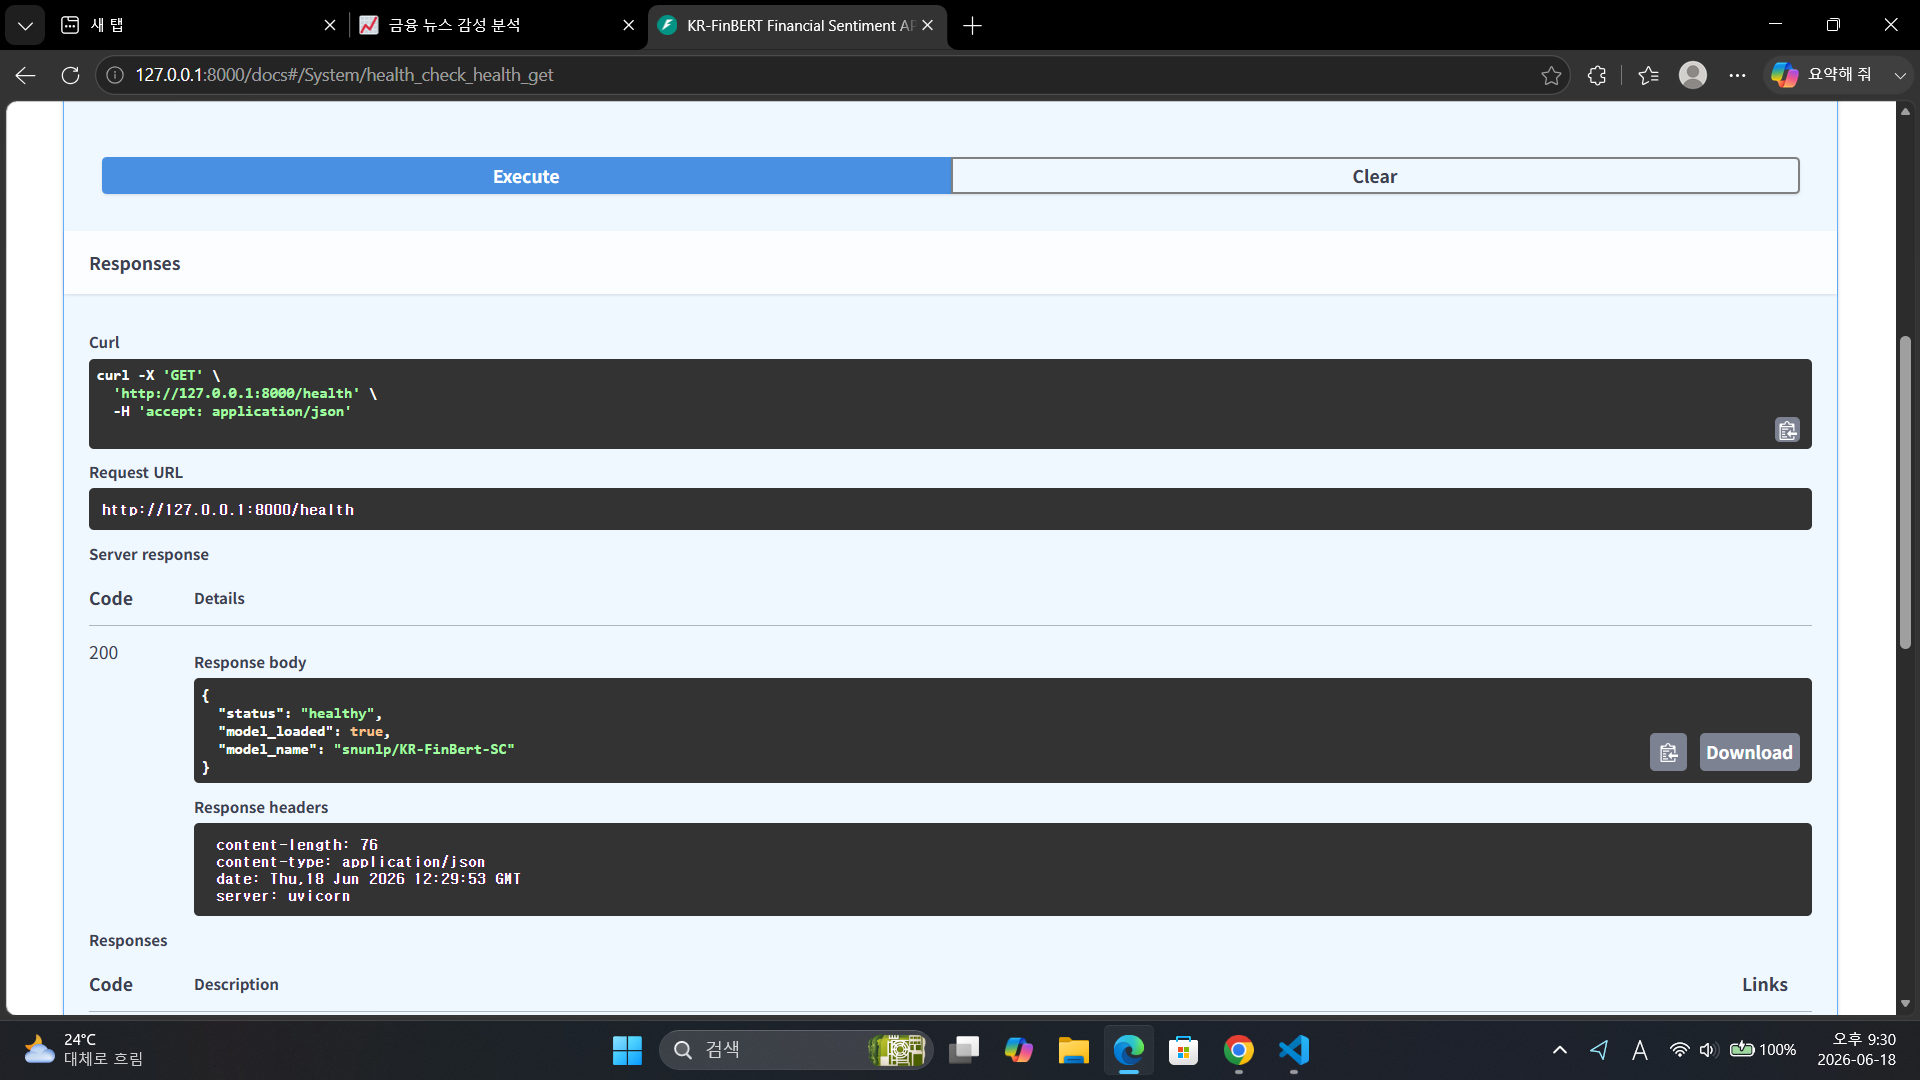
swaggerUI로 실행   
서버는 건강합니다.

api 인증 테스트

In [13]:
import requests

API_URL = "http://localhost:8000"
HEADERS = {"X-API-Key": "test-key-001"}

# health check
print(requests.get(f"{API_URL}/health").json())

# 추론 테스트 — 본인의 입력에 맞게 수정하세요
response = requests.post(
    f"{API_URL}/predict",
    json={"text": "삼성 4분기 실적이 15% 증가해 상여금이 나올것으로 예상됩니다."},   # ← 수정
    headers=HEADERS,
)
print(f"상태: {response.status_code}")
print(f"결과: {response.json()}")

{'status': 'healthy', 'model_loaded': True, 'model_name': 'snunlp/KR-FinBert-SC'}
상태: 200
결과: {'success': True, 'label': 'positive', 'confidence': 0.7333}


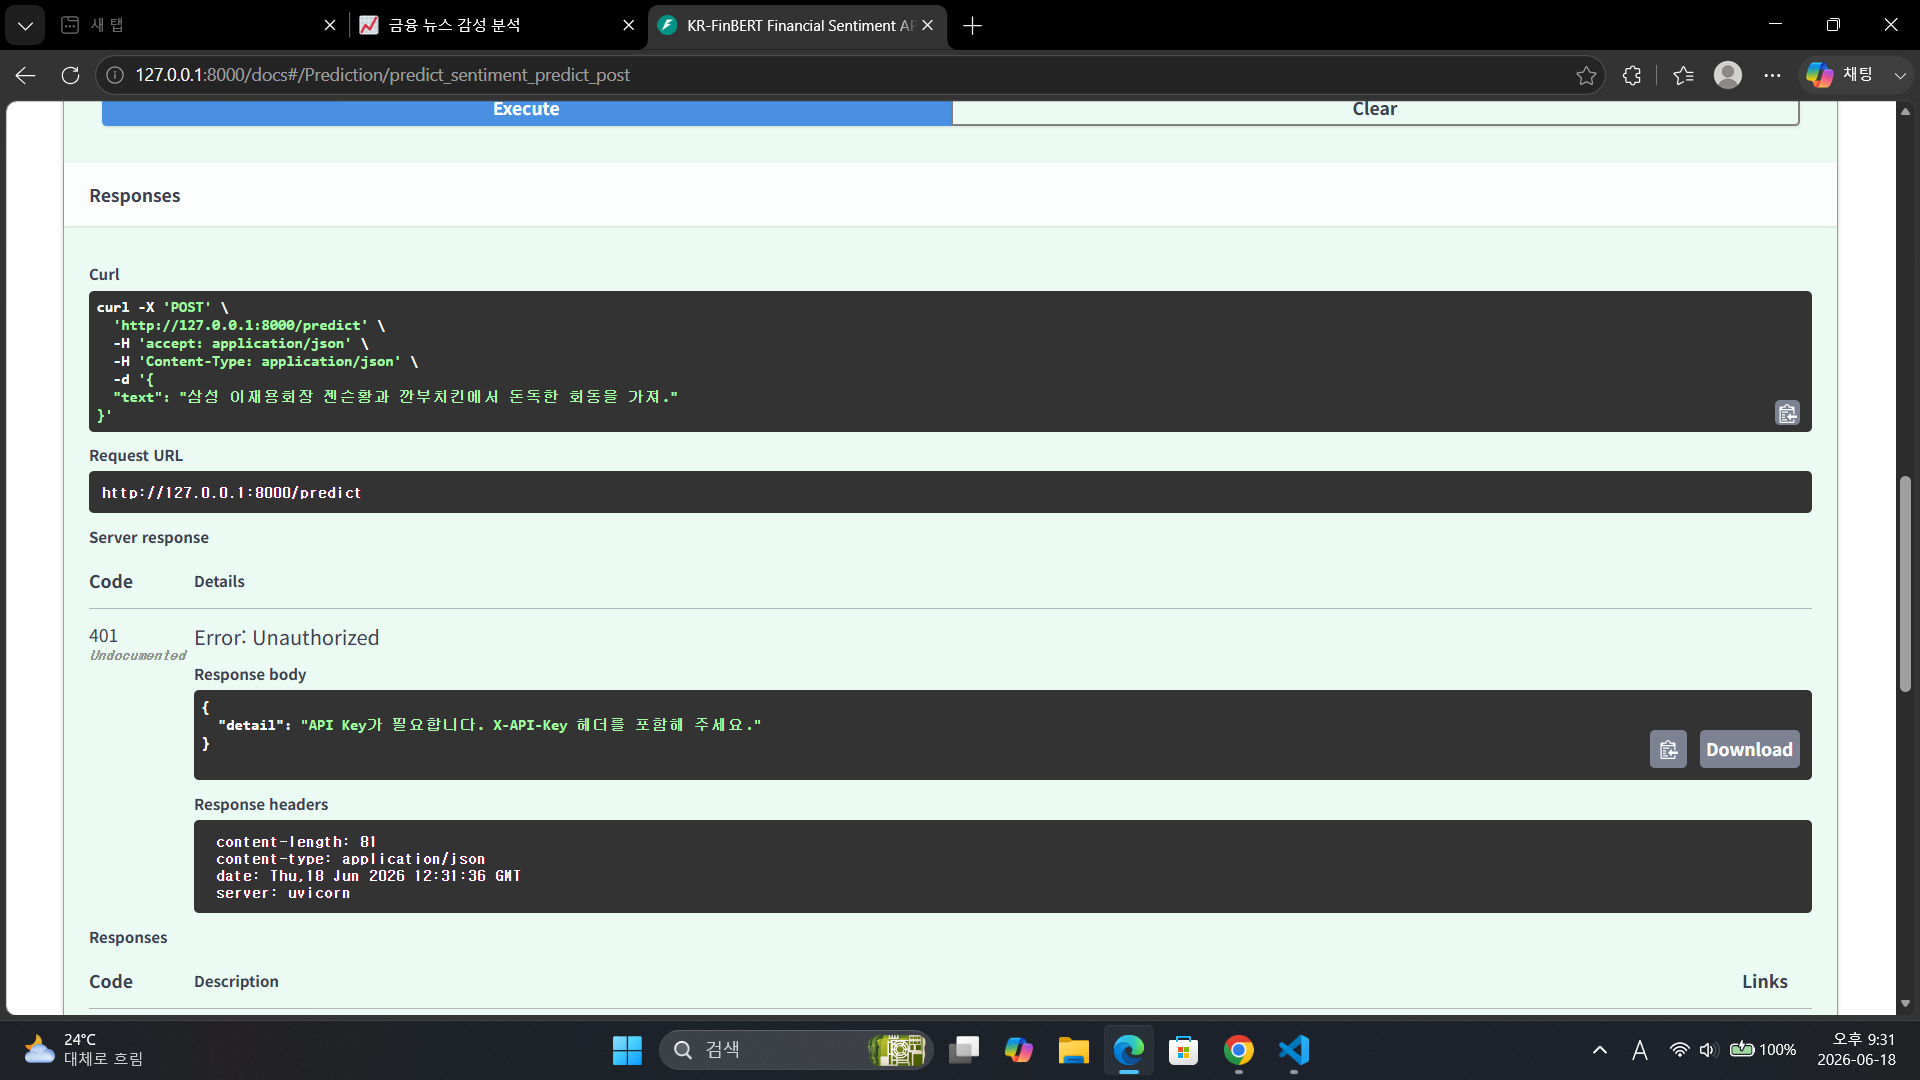
apikey 미 입력시   

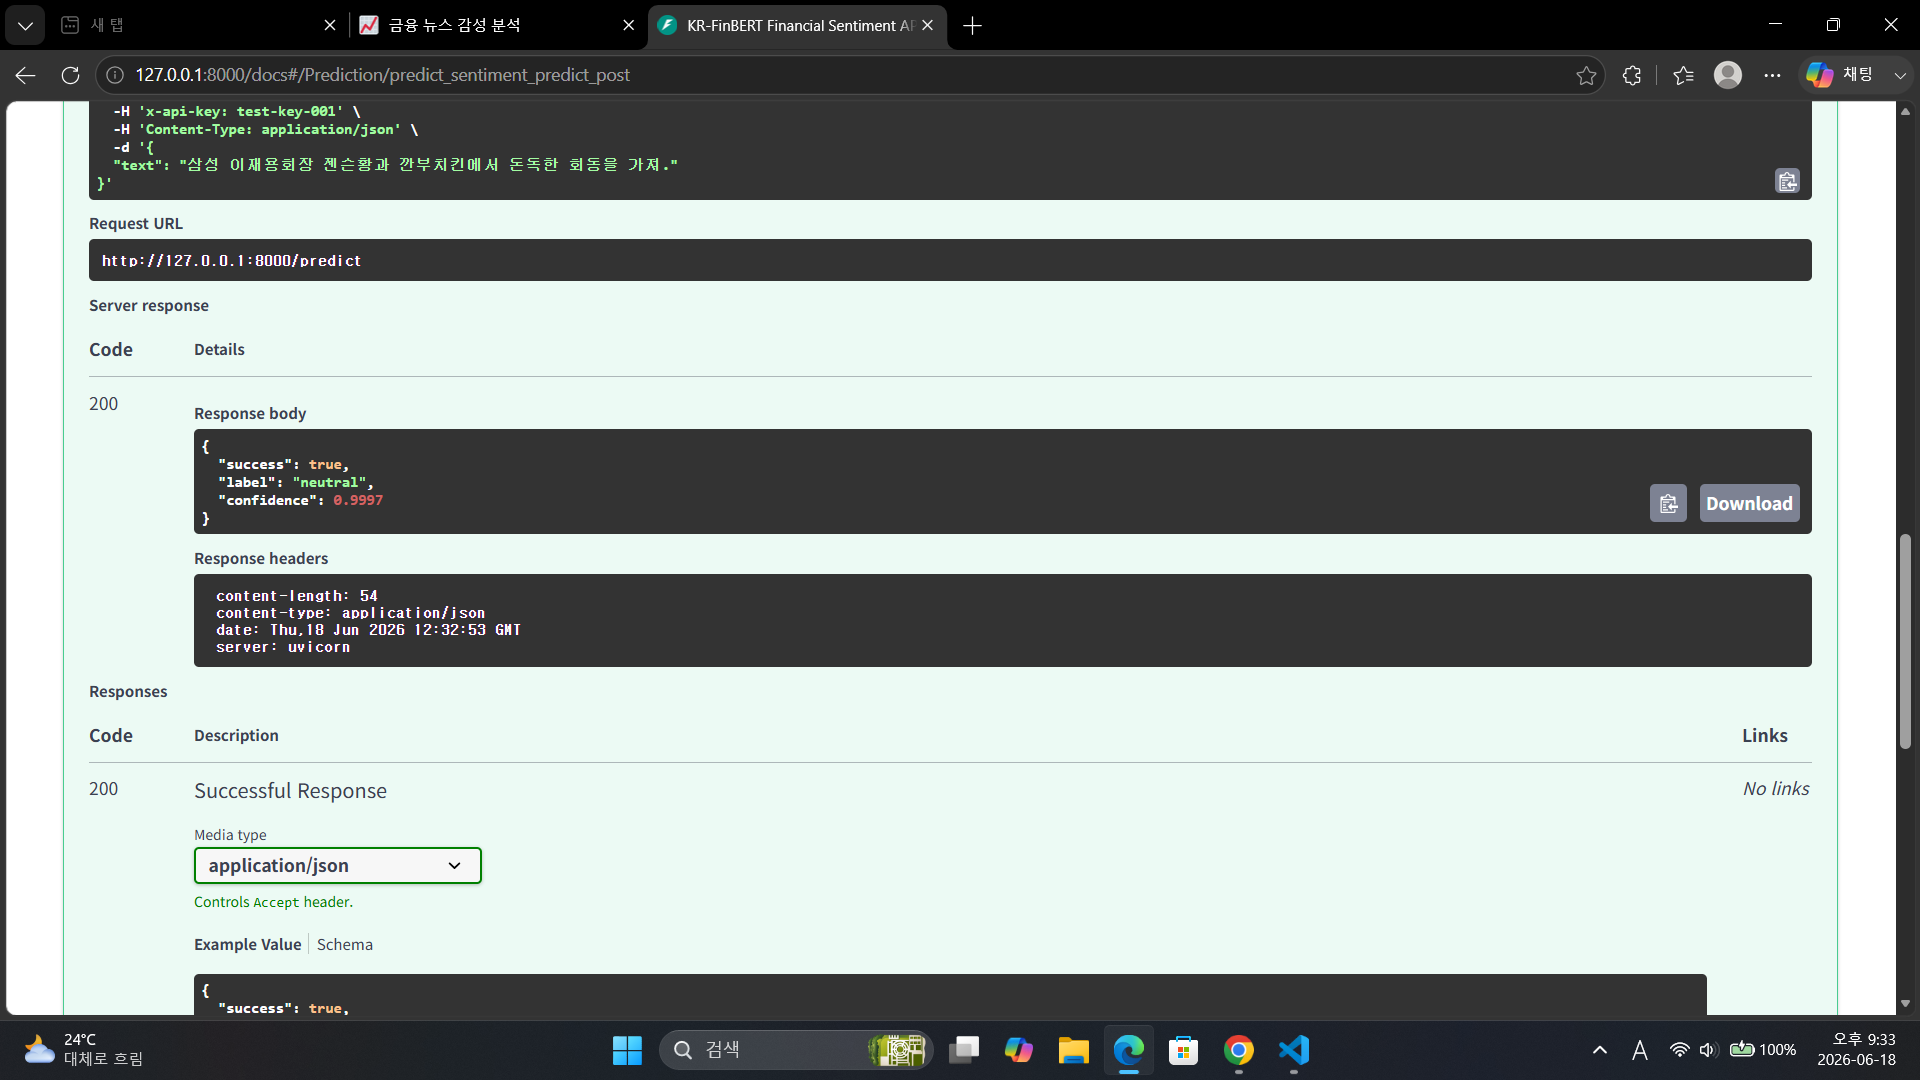
apikey 인증후 답변 생성 성공.   
깐부치킨에 대해 매우 중립적인 것으로 보인다.

streamlit으로 실행

In [14]:
!streamlit run frontend/app.py

^C


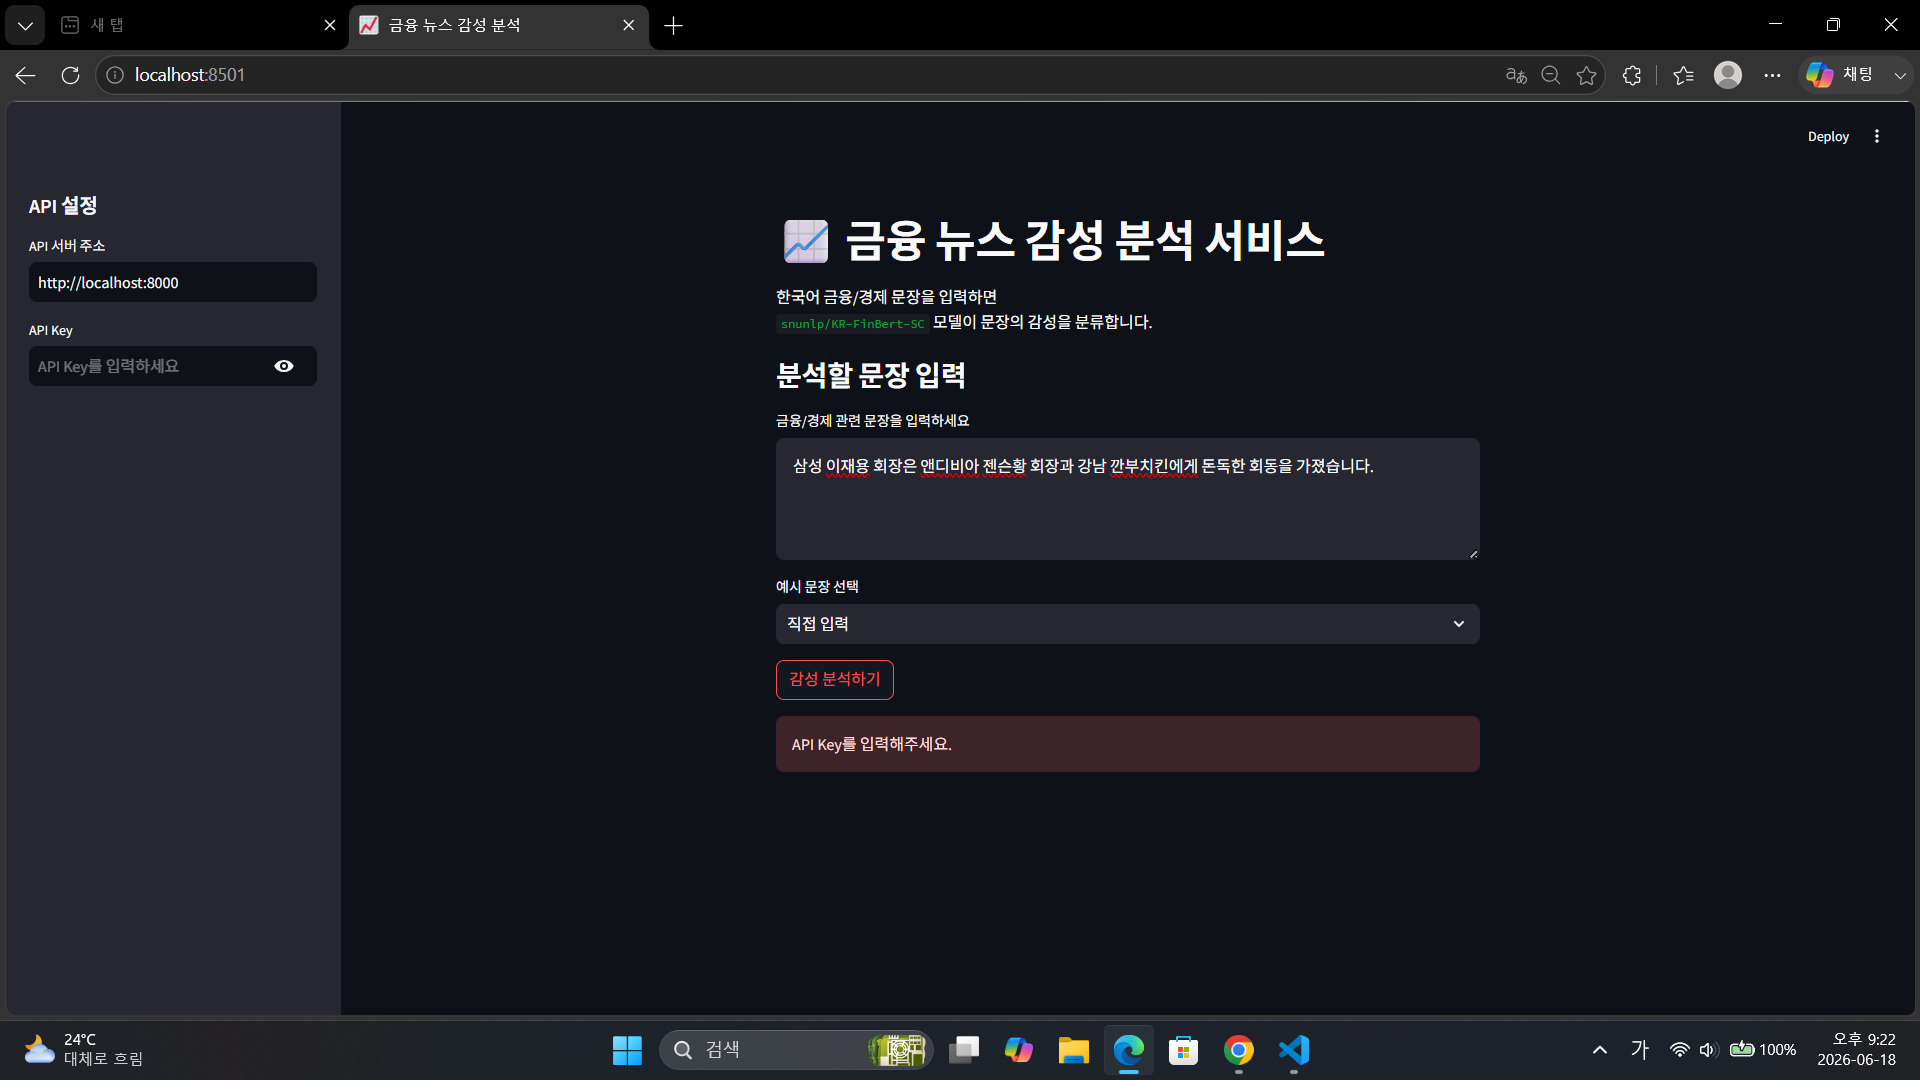
실제 사용자들에게 보일 Straemlit

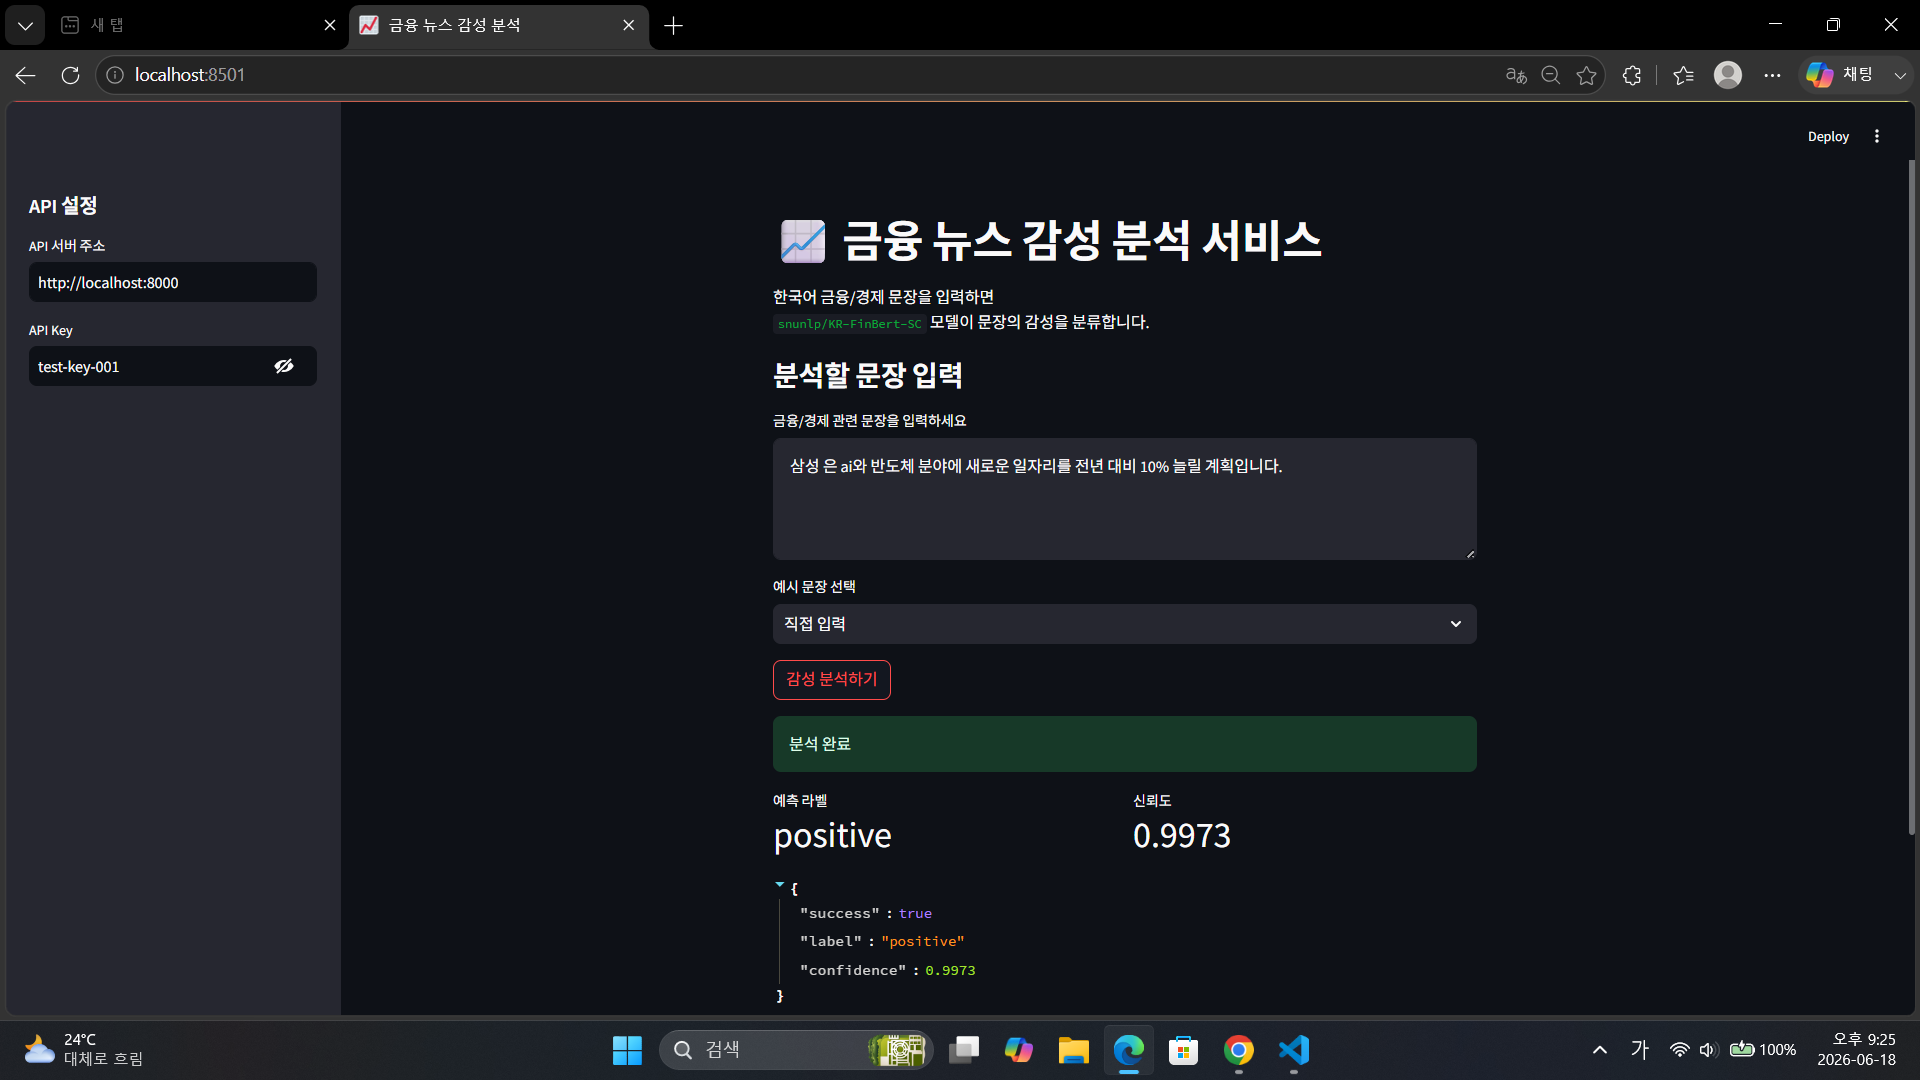
apikey 인증후 답변 생성 성공.   
경제학도 스러운 질문에 긍정적인 답변을 얻었다.

Q1. 본인의 프로젝트에서 Pydantic 검증은 어떤 잘못된 입력을 막아줍니까? Pydantic 검증은 /predict 요청에서 잘못된 text 입력을 막아줍니다. text가 안 들어가거나 너무 긴 문장을 방지해 줍니다.  

Q2. Depends(verify_api_key)를 제거하면 어떤 위험이 있습니까? 인증 되지 않은 사용자가 무수히 많은 요청을 보내 서버를 공격하거나 서버다운, 비용폭탄, 모델 도용 등의 위험이 있습니다.   

Q3. run_in_executor를 사용한 이유는 무엇입니까? 모델추론과 같이 이벤트루프가 블락킹되는 동기 함수를 별도의 스레드풀에 옴겨서 실행하여 동시 처리 할수 있고 요청과 같이 비동기 작업들을 효율적으로 처리하게 할 수 있습니다.   

Q4. Day 1~8 중 가장 많이 참고한 Day는 어디였습니까? 왜? 프론트엔드 부분은 Day 4의 Streamlit 구조를 많이 참고했습니다. 모델 정의나 API로 감싸는 부분은 비교적 이해하기 쉬웠지만, 사용자 입력을 받고 API를 호출한 뒤 결과를 화면에 보기 좋게 표시하는 부분은 Streamlit 예제가 많은 도움이 되었습니다.   

Q5. 이 서비스를 실제로 배포하려면 추가로 무엇이 필요합니까? 서버를 안정적으로 실행할 배포 환경이 필요합니다. 예를 들어 클라우드 서버, GPU 또는 CPU 서버, 배포용 웹 서버 설정 등이 필요합니다. 또한 지금은 코드 안에 API Key를 직접 적을 수 있지만, 실제 배포에서는 환경 변수로 관리해야 합니다.
추가로 Docker 같은 컨테이너 패키징, HTTPS 설정, CORS 설정, 로그 관리, 모니터링, 에러 추적, 요청 제한(rate limiting), 모델 파일 캐싱, 서버 재시작 정책 등이 필요합니다.

회고   
day8까지 오면서 만들고 싶었던 모델을 활용한 서비스가 없어서 아쉽게도 노트북에 있는 예제 모델을 활용해 백엔드와 프론트 엔드를 구축했습니다. 스키마와 pydantic을 통해 모델 서비스에 입력과 출력이 어떻게 정의하고 통제할지에 대해 배웠고 apikey와 run_in_executor 등을 활용해서 서비스가 어떻게 강건해지고 비동기적 요청,응답 관리하는 지도 알았습니다. 또한 예외처리와 에러관리를 로깅화 해야지 사후 대처가 용이하고 백엔드와 프론트엔드를 분리해야 하는지도 더 깊게 실감했습니다. 기존에 배운 내용들을 총정리하는 시간이였고 다른 그루분들의 발표를 보며 놀라운 아이디어들을 접하게 되서 나도 뭔가 응용해서 만들어 보고 싶어졌습니다.